# Resultados e Comparação de Algoritmos
Este notebook executa os scripts principais (`main.py` e `main_td.py`) para treinar os modelos Q-Learning e SARSA, compara métricas de avaliação e explora variações na taxa de aprendizado (`alpha`).

Passos principais:
1. Executar `main.py` e `main_td.py` para gerar resultados atuais.
2. Carregar métricas e trajetórias de treinamento salvas em `resultados/`.
3. Plotar comparações de desempenho e curvas de aprendizagem.
4. Rodar um experimento de variação de `alpha` para cada algoritmo.


In [13]:
# Configuração de importações e helpers
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import main as q_main
import main_td
from helpers.data_loader import load_train_data, load_test_data
from ambiente.portfolio_env import PortfolioEnv
from agentes.Q_learning import AgentQLearning
from agentes.TD_learning import AgentTD

RESULTS_DIR = ROOT / "resultados"


def load_json(path):
    return json.loads(Path(path).read_text())


def load_saved_results():
    q_metrics = load_json(RESULTS_DIR / "metrics_qlearning.json")
    td_metrics = load_json(RESULTS_DIR / "metrics_td.json")
    q_history = load_json(RESULTS_DIR / "training_history.json")
    td_history = load_json(RESULTS_DIR / "training_history_td.json")
    q_eval = load_json(RESULTS_DIR / "eval_portfolio.json")
    td_eval = load_json(RESULTS_DIR / "eval_portfolio_td.json")
    return q_metrics, td_metrics, q_history, td_history, q_eval, td_eval


def show_metrics_table(q_metrics, td_metrics):
    df = pd.DataFrame([
        {
            "algorithm": "Q-Learning",
            "final_value": q_metrics["agent"]["final_value"],
            "total_return": q_metrics["agent"]["total_return"],
            "sharpe_ratio": q_metrics["agent"]["sharpe_ratio"],
            "max_drawdown": q_metrics["agent"]["max_drawdown"],
        },
        {
            "algorithm": "TD_LEARNING (TD)",
            "final_value": td_metrics["agent"]["final_value"],
            "total_return": td_metrics["agent"]["total_return"],
            "sharpe_ratio": td_metrics["agent"]["sharpe_ratio"],
            "max_drawdown": td_metrics["agent"]["max_drawdown"],
        },
    ])
    display(df.style.format({
        "final_value": "R$ {:,.2f}",
        "total_return": "{:.2%}",
        "sharpe_ratio": "{:.4f}",
        "max_drawdown": "{:.2%}",
    }))
    return df


def plot_training_history(q_history, td_history):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes[0, 0].plot(q_history["episode_rewards"], label="Q-Learning")
    axes[0, 0].plot(td_history["episode_rewards"], label="TD_LEARNING")
    axes[0, 0].set_title("Reward por episódio")
    axes[0, 0].set_xlabel("Episódio")
    axes[0, 0].set_ylabel("Reward")
    axes[0, 0].legend()

    axes[0, 1].plot(q_history["episode_portfolio_values"], label="Q-Learning")
    axes[0, 1].plot(td_history["episode_portfolio_values"], label="TD_LEARNING")
    axes[0, 1].set_title("Valor final do portfólio por episódio")
    axes[0, 1].set_xlabel("Episódio")
    axes[0, 1].set_ylabel("Valor final (R$)")
    axes[0, 1].legend()

    axes[1, 0].plot(q_history["episode_epsilons"], label="Q-Learning")
    axes[1, 0].plot(td_history["episode_epsilons"], label="TD_LEARNING")
    axes[1, 0].set_title("Epsilon ao final de cada episódio")
    axes[1, 0].set_xlabel("Episódio")
    axes[1, 0].set_ylabel("ε")
    axes[1, 0].legend()

    axes[1, 1].plot(q_history["episode_alphas"], label="Q-Learning")
    axes[1, 1].plot(td_history["episode_alphas"], label="TD_LEARNING")
    axes[1, 1].set_title("Alpha ao final de cada episódio")
    axes[1, 1].set_xlabel("Episódio")
    axes[1, 1].set_ylabel("α")
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()


def plot_eval_portfolios(q_eval, td_eval):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(q_eval["portfolio_values"], label="Q-Learning")
    ax.plot(td_eval["portfolio_values"], label="TD_LEARNING (TD)")
    ax.set_title("Valor do portfólio no conjunto de teste")
    ax.set_xlabel("Passos de teste")
    ax.set_ylabel("Valor do portfólio (R$)")
    ax.legend()
    ax.grid(True)
    plt.show()


def run_learning_rate_experiment(agent_cls, label, alpha_values, n_episodes=200):
    train_df = load_train_data()
    test_df = load_test_data()
    env_config = q_main.ENV_CONFIG
    agent_config = q_main.AGENT_CONFIG.copy() if agent_cls is AgentQLearning else main_td.AGENT_CONFIG.copy()

    records = []
    for alpha in alpha_values:
        config = agent_config.copy()
        config["alpha"] = alpha
        config["alpha_min"] = max(alpha * 0.1, 0.001)
        config["alpha_decay"] = 0.995
        config["epsilon"] = 1.0
        config["epsilon_min"] = 0.01
        config["epsilon_decay"] = 0.995

        print(f"\n=== {label}: alpha={alpha} | episódios={n_episodes} ===")
        env_for_init = PortfolioEnv(train_df, **env_config)
        agent = agent_cls(env_for_init, **config)
        history = agent.train(PortfolioEnv(train_df, **env_config), n_episodes=n_episodes, log_interval=max(1, n_episodes // 4))
        eval_results = agent.evaluate(PortfolioEnv(test_df, **env_config))

        records.append({
            "algorithm": label,
            "alpha": alpha,
            "final_value": eval_results["final_value"],
            "total_return": eval_results["total_return"],
            "sharpe_ratio": eval_results["sharpe_ratio"],
            "max_drawdown": eval_results["max_drawdown"],
            "avg_reward_last_50": np.mean(history["episode_rewards"][-50:]),
            "n_states_visited": history["n_states_visited"],
        })

    return pd.DataFrame(records)


def plot_alpha_experiment(df):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for name, group in df.groupby("algorithm"):
        axes[0, 0].plot(group["alpha"], group["total_return"], marker="o", label=name)
        axes[0, 1].plot(group["alpha"], group["sharpe_ratio"], marker="o", label=name)
        axes[1, 0].plot(group["alpha"], group["final_value"], marker="o", label=name)
        axes[1, 1].plot(group["alpha"], group["max_drawdown"], marker="o", label=name)

    axes[0, 0].set_title("Retorno total vs α")
    axes[0, 0].set_xlabel("α")
    axes[0, 0].set_ylabel("Retorno total")
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    axes[0, 1].set_title("Sharpe vs α")
    axes[0, 1].set_xlabel("α")
    axes[0, 1].set_ylabel("Sharpe Ratio")
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    axes[1, 0].set_title("Valor final do portfólio vs α")
    axes[1, 0].set_xlabel("α")
    axes[1, 0].set_ylabel("Valor final (R$)")
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    axes[1, 1].set_title("Max Drawdown vs α")
    axes[1, 1].set_xlabel("α")
    axes[1, 1].set_ylabel("Max Drawdown")
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()


In [ ]:
# 1. Executar os mains para treinar os modelos
print("Executando main.py (Q-Learning)...")
q_main.main()
print("\nExecutando main_td.py (TD_LEARNING)...")
main_td.main()
print("\nTreinamentos concluídos. Resultados salvos em 'resultados/'.")


Métricas consolidadas dos agentes


,algorithm,final_value,total_return,sharpe_ratio,max_drawdown
0,Q-Learning,"R$ 99,930.75",-0.07%,0.0836,13.06%
1,TD_LEARNING (TD),"R$ 98,590.33",-1.41%,-0.0352,13.14%


Plot de métricas de treinamento


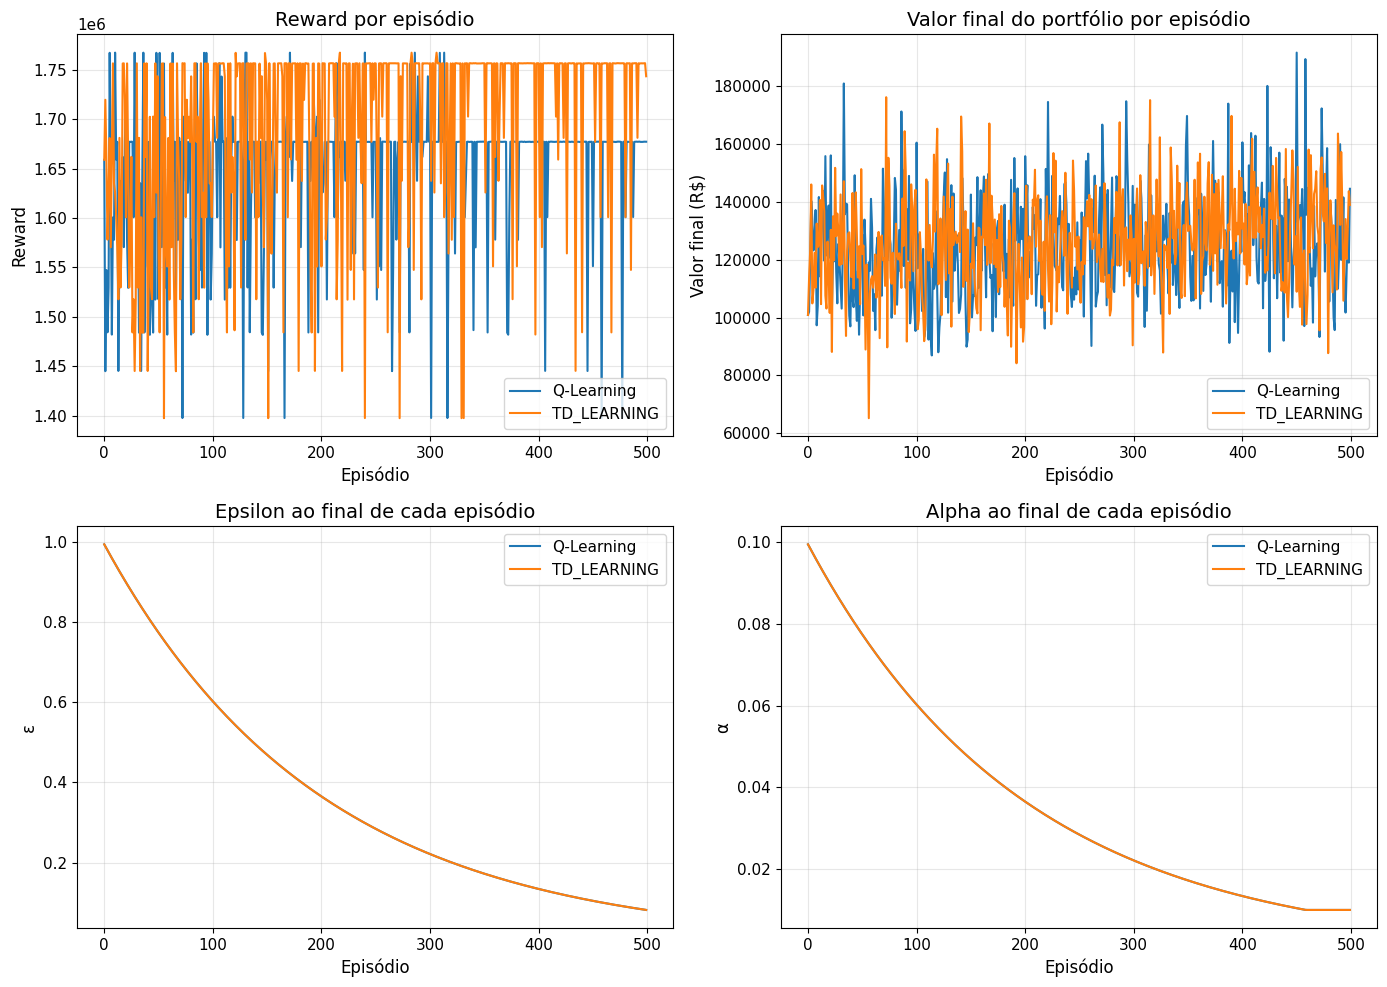

Trajetória de valor do portfólio no teste


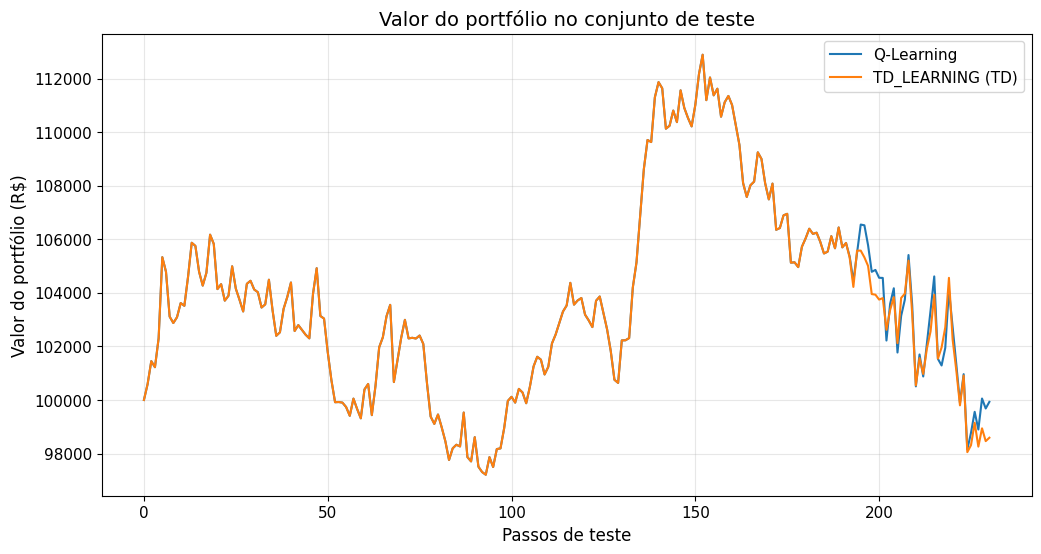

In [14]:
# 2. Carregar resultados salvos e comparar desempenho
q_metrics, td_metrics, q_history, td_history, q_eval, td_eval = load_saved_results()

print("Métricas consolidadas dos agentes")
metrics_df = show_metrics_table(q_metrics, td_metrics)

print("Plot de métricas de treinamento")
plot_training_history(q_history, td_history)

print("Trajetória de valor do portfólio no teste")
plot_eval_portfolios(q_eval, td_eval)


[data_loader] Treino carregado: 1227 registros (2019-01-03 → 2023-12-28)
[data_loader] Teste carregado:  251 registros (2024-01-02 → 2024-12-30)

=== Q-Learning: alpha=0.02 | episódios=200 ===
[Q-Learning] Calculando bins de discretização (10 episódios aleatórios)...
[Q-Learning] Bins calculados para 18 features.

  Q-LEARNING TREINAMENTO — 200 episódios
  α=0.02, γ=0.99, ε=1.0, bins=5

  Ep    1/200 | Reward: 1659035.67 | Avg(50): 1659035.67 | Value: R$ 100,923.05 | ε: 0.9950 | α: 0.0199 | Q-states: 1,199
  Ep   50/200 | Reward: 1445262.39 | Avg(50): 1607104.96 | Value: R$ 123,145.66 | ε: 0.7783 | α: 0.0156 | Q-states: 49,632
  Ep  100/200 | Reward: 1637435.77 | Avg(50): 1616800.40 | Value: R$ 94,626.85 | ε: 0.6058 | α: 0.0121 | Q-states: 84,138
  Ep  150/200 | Reward: 1677392.76 | Avg(50): 1651105.41 | Value: R$ 133,941.20 | ε: 0.4715 | α: 0.0094 | Q-states: 110,115
  Ep  200/200 | Reward: 1484346.58 | Avg(50): 1650151.71 | Value: R$ 118,372.89 | ε: 0.3670 | α: 0.0073 | Q-states: 130

,algorithm,alpha,final_value,total_return,sharpe_ratio,max_drawdown,avg_reward_last_50,n_states_visited
0,Q-Learning,0.020000,"R$ 94,184.03",-5.82%,-0.3658,16.57%,1650151.71,130620
1,Q-Learning,0.050000,"R$ 99,422.80",-0.58%,0.0451,13.50%,1634366.86,131300
2,Q-Learning,0.100000,"R$ 99,930.75",-0.07%,0.0836,13.06%,1655387.24,130935
3,Q-Learning,0.200000,"R$ 94,184.03",-5.82%,-0.3658,16.57%,1646080.16,131899
4,TD_LEARNING (TD),0.020000,"R$ 98,617.95",-1.38%,-0.0301,13.12%,1684946.42,130245
5,TD_LEARNING (TD),0.050000,"R$ 99,919.03",-0.08%,0.0773,13.07%,1710129.10,129965
6,TD_LEARNING (TD),0.100000,"R$ 98,590.33",-1.41%,-0.0352,13.14%,1688301.82,131211
7,TD_LEARNING (TD),0.200000,"R$ 98,590.33",-1.41%,-0.0352,13.14%,1702731.94,128867


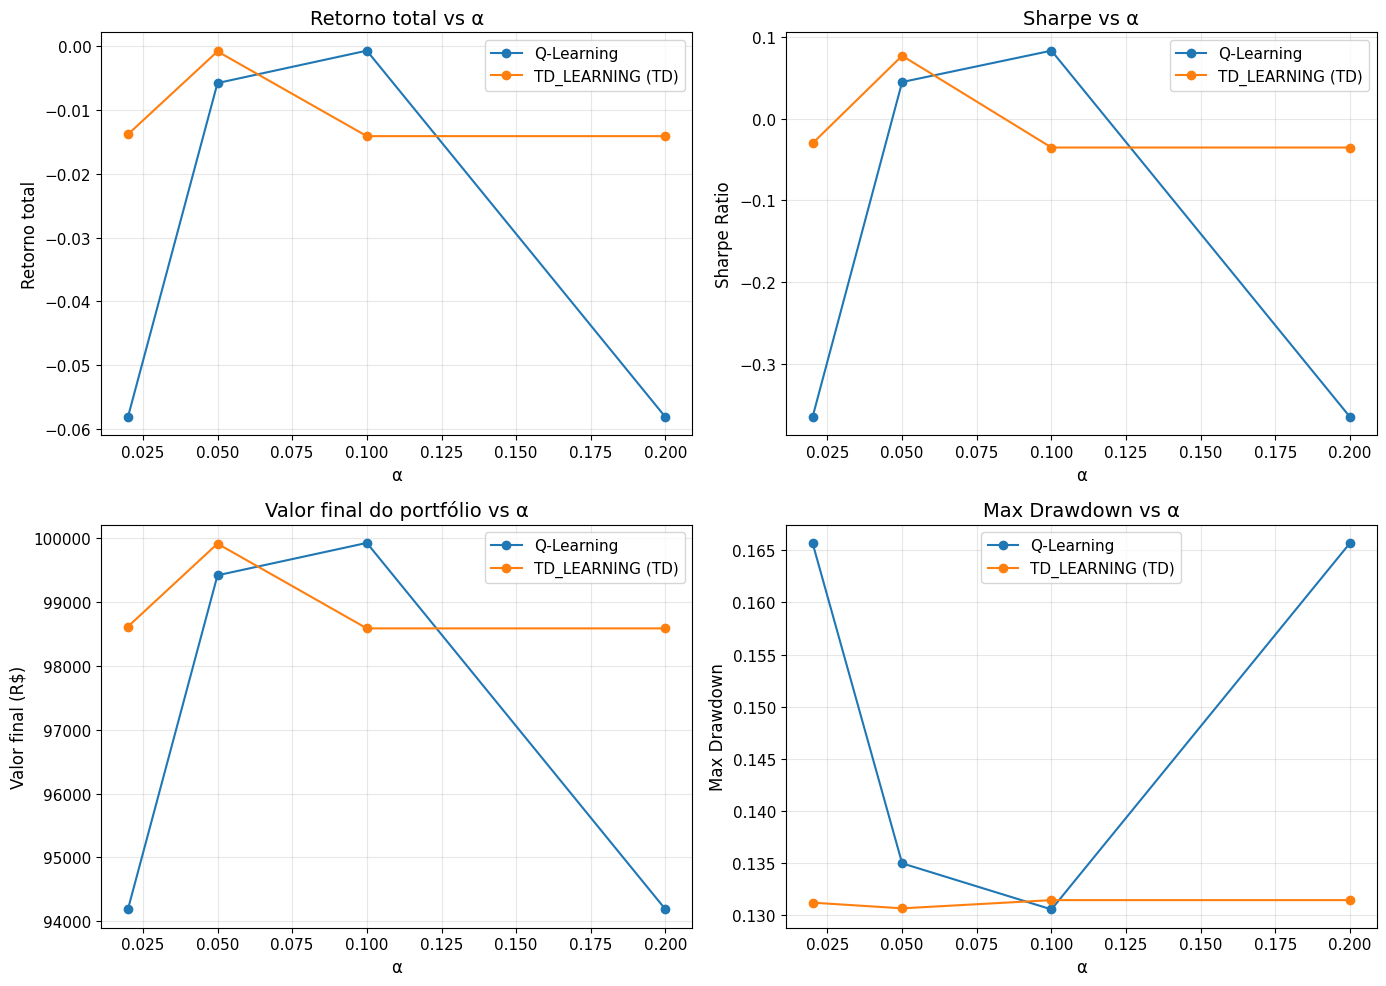

In [15]:
# 3. Experimento de sensibilidade à taxa de aprendizagem (alpha)
alpha_values = [0.02, 0.05, 0.1, 0.2]
q_alpha_results = run_learning_rate_experiment(AgentQLearning, "Q-Learning", alpha_values, n_episodes=200)
td_alpha_results = run_learning_rate_experiment(AgentTD, "TD_LEARNING (TD)", alpha_values, n_episodes=200)

alpha_df = pd.concat([q_alpha_results, td_alpha_results], ignore_index=True)
display(alpha_df.style.format({
    "final_value": "R$ {:,.2f}",
    "total_return": "{:.2%}",
    "sharpe_ratio": "{:.4f}",
    "max_drawdown": "{:.2%}",
    "avg_reward_last_50": "{:.2f}",
}))

plot_alpha_experiment(alpha_df)


## Conclusões e próximos passos

- Agora você tem um notebook que:
  - treina `main.py` (Q-Learning) e `main_td.py` (SARSA);
  - compara métricas de desempenho e curvas de treinamento;
  - explora a sensibilidade à taxa de aprendizado (`alpha`).

- Para aprofundar a análise, experimente também variar:
  - `epsilon_decay` e `alpha_decay`;
  - `transaction_cost` e `weight_delta` no ambiente;
  - número de bins (`n_bins`) para discretização.

- Os resultados de comparação ficam salvos em `resultados/` e podem ser reutilizados em novos notebooks ou relatórios.


  MÉTRICAS DE COMPARAÇÃO — Q-Learning vs TD_LEARNING

1. Recompensa Acumulada por Episódio...


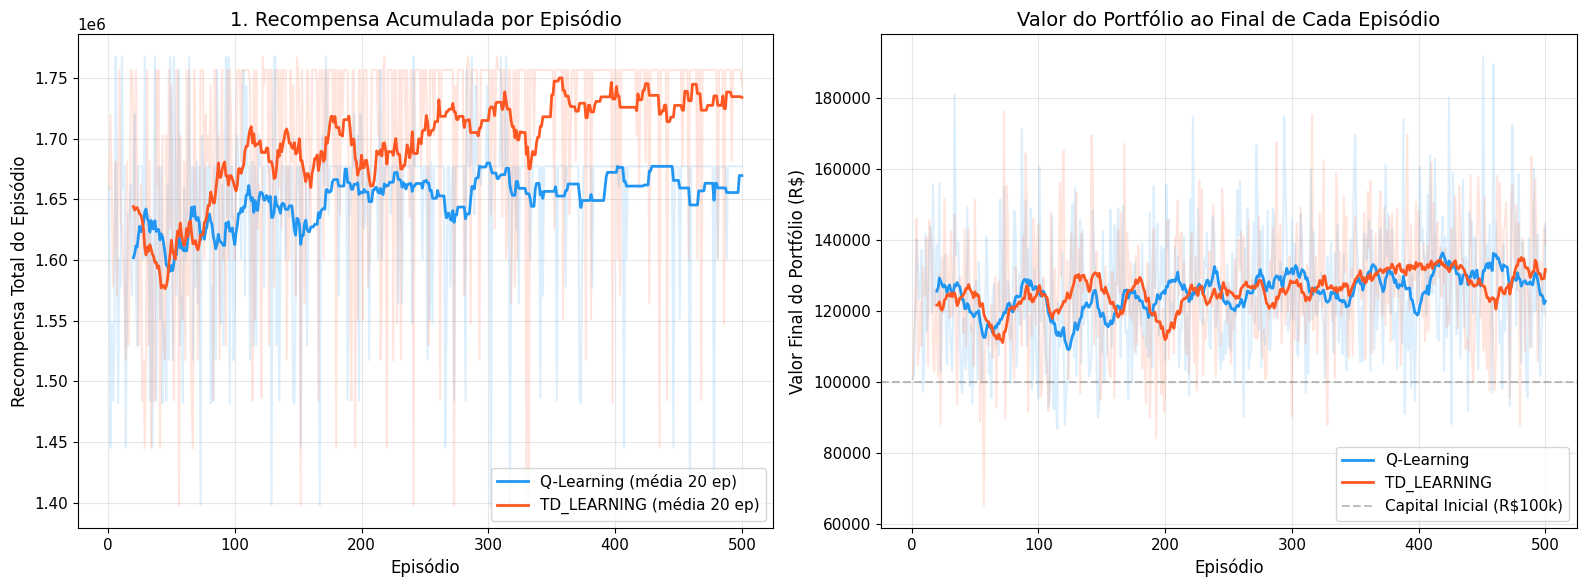

  Salvo em: /home/jean/Documents/rl-wallet-b3/resultados/figuras/01_reward_curve.png

2. Convergência da Função de Valor...


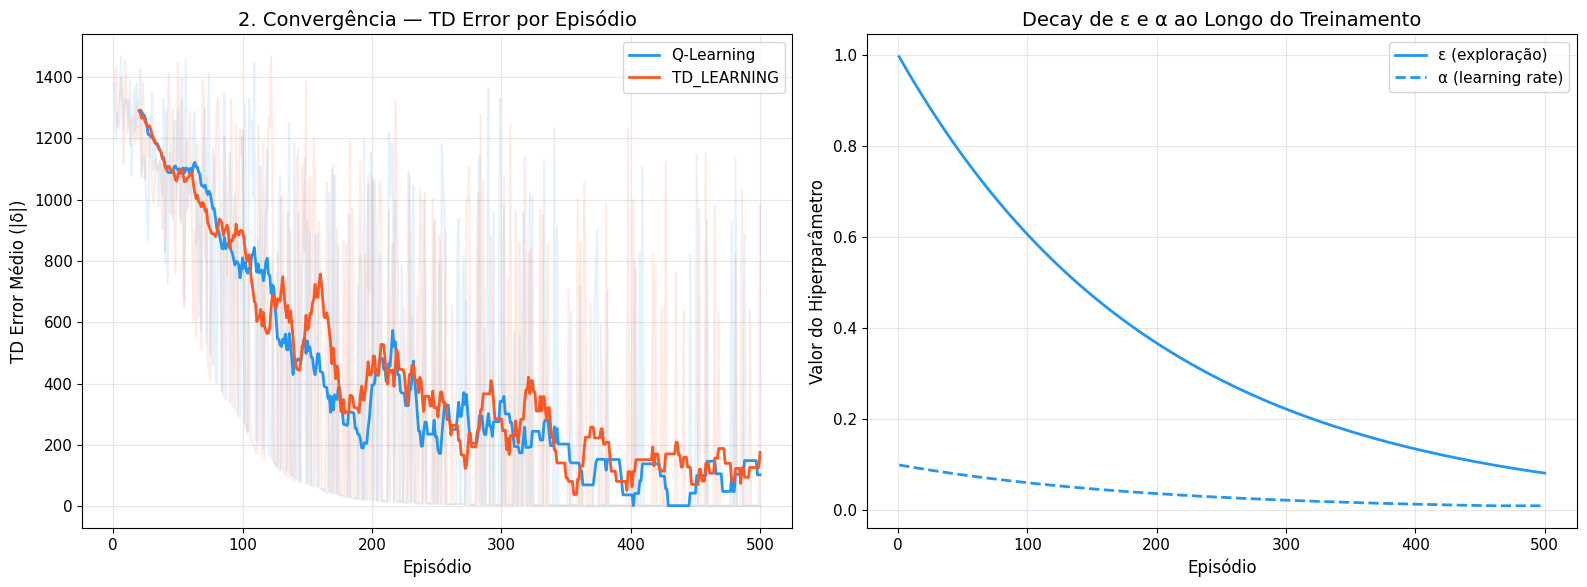

  Salvo em: /home/jean/Documents/rl-wallet-b3/resultados/figuras/02_convergence.png

3. Eficiência de Amostra...


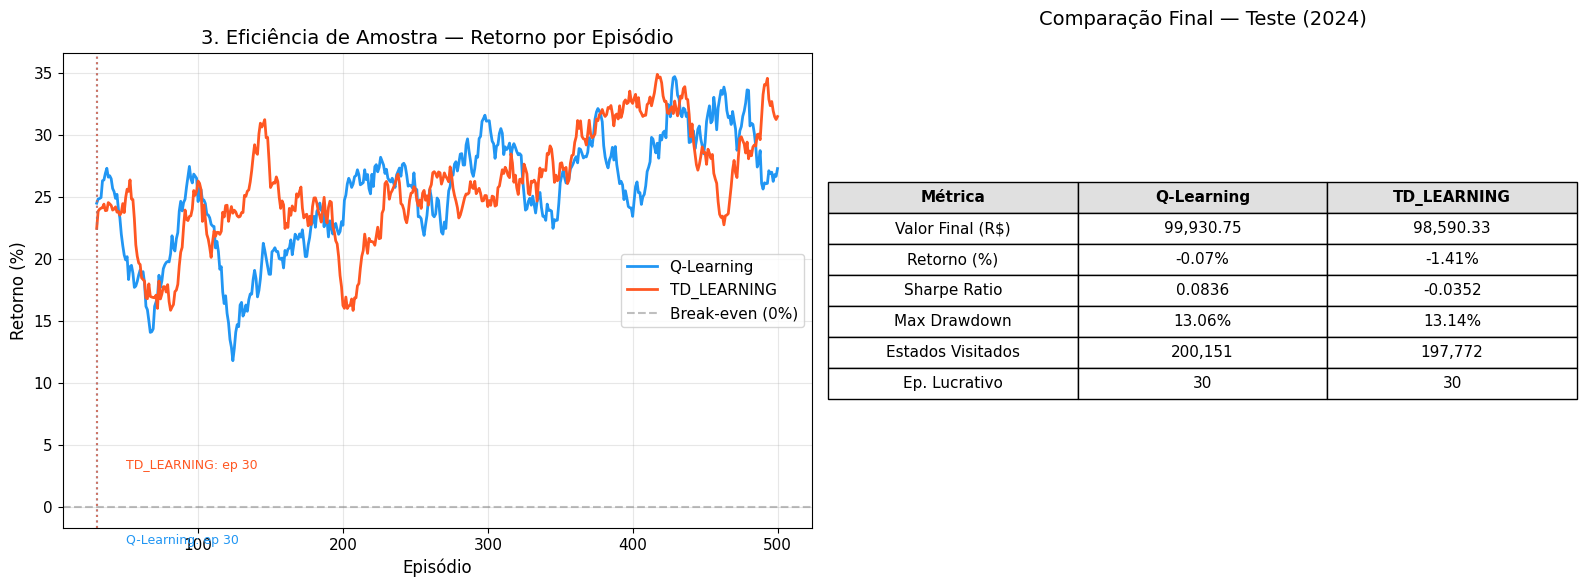

  Salvo em: /home/jean/Documents/rl-wallet-b3/resultados/figuras/03_sample_efficiency.png

4. Sensibilidade ao Learning Rate (α)...

  Treinando com diferentes learning rates...
  (isso pode levar alguns minutos)

[data_loader] Treino carregado: 1227 registros (2019-01-03 → 2023-12-28)
    α = 0.01...
[Q-Learning] Calculando bins de discretização (3 episódios aleatórios)...
[Q-Learning] Bins calculados para 18 features.

  Q-LEARNING TREINAMENTO — 100 episódios
  α=0.01, γ=0.99, ε=1.0, bins=5

  Ep    1/100 | Reward: 1659035.67 | Avg(999): 1659035.67 | Value: R$ 100,923.05 | ε: 0.9950 | α: 0.0100 | Q-states: 1,190

  TREINAMENTO CONCLUÍDO
  Estados visitados: 83,231
  ε final: 0.6058
  α final: 0.0061
  Reward médio (últimos 50): 1655694.33

[TD_LEARNING] Calculando bins de discretização (3 episódios aleatórios)...
[TD_LEARNING] Bins calculados para 18 features.

  TD_LEARNING (TD) TREINAMENTO — 100 episódios
  α=0.01, γ=0.99, ε=1.0, bins=5

  Ep    1/100 | Reward: 1659035.67 | Avg(999

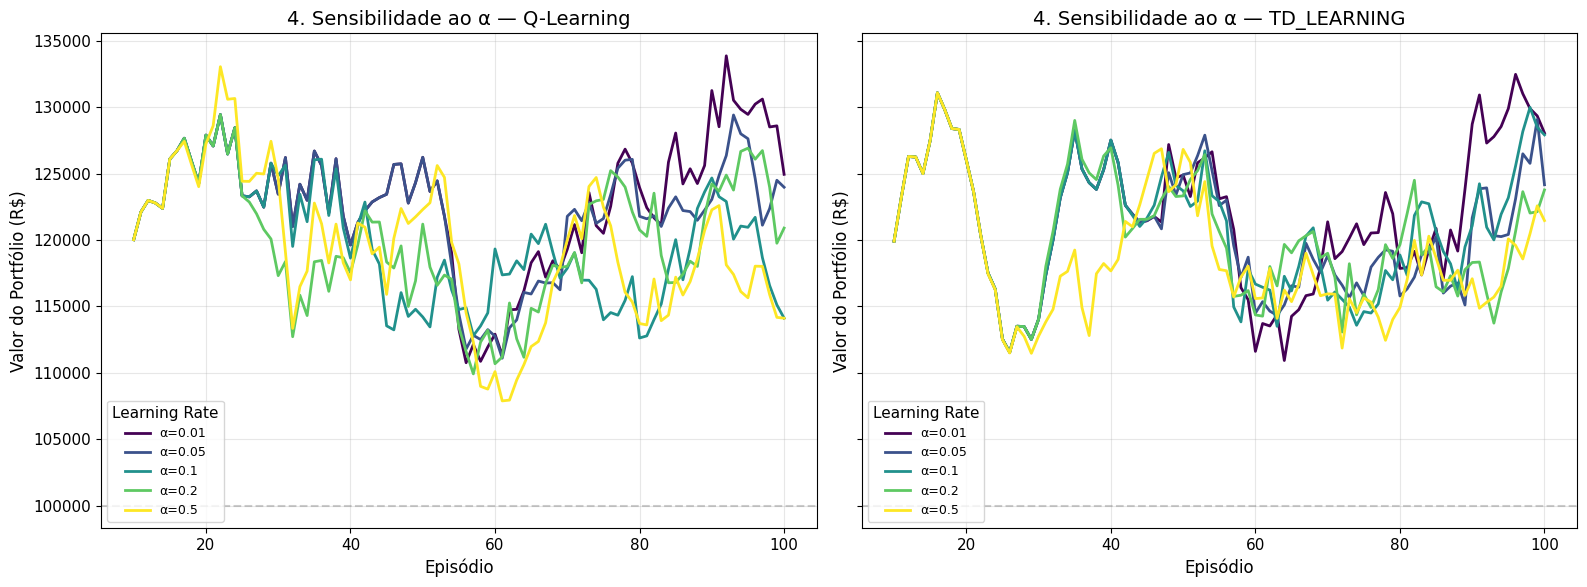

  Salvo em: /home/jean/Documents/rl-wallet-b3/resultados/figuras/04_alpha_sensitivity.png

  Todas as figuras salvas em: /home/jean/Documents/rl-wallet-b3/resultados/figuras


In [16]:
"""
metricas.py — Comparação Q-Learning vs TD_LEARNING com gráficos.

Métricas:
  1. Recompensa Acumulada por Episódio (Reward Curve)
  2. Convergência da Função de Valor (Q-Value / TD Error)
  3. Eficiência de Amostra (Sample Efficiency)
"""

import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Adiciona raiz do projeto ao path
PROJECT_ROOT = Path.cwd().resolve().parents[0]


sys.path.insert(0, PROJECT_ROOT)

RESULTS_DIR = os.path.join(PROJECT_ROOT, "resultados")
FIGURES_DIR = os.path.join(RESULTS_DIR, "figuras")
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Configuração visual ──────────────────────────────────────────────
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

COLORS = {"qlearning": "#2196F3", "TD_LEARNING": "#FF5722"}


def load_history(filename):
    with open(os.path.join(RESULTS_DIR, filename)) as f:
        return json.load(f)


def smooth(values, window=20):
    """Média móvel simples para suavizar curvas."""
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")


# 1. RECOMPENSA ACUMULADA POR EPISÓDIO (Reward Curve)

def plot_reward_curve():
    """
    Métrica 'rei' do RL — soma total de recompensas por episódio.
    Equivalente à Acurácia em aprendizado supervisionado.
    """
    q_hist = load_history("training_history.json")
    td_hist = load_history("training_history_td.json")

    q_rewards = q_hist["episode_rewards"]
    td_rewards = td_hist["episode_rewards"]
    episodes = range(1, len(q_rewards) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # --- Painel 1: Curvas brutas + suavizadas ---
    ax = axes[0]
    ax.plot(episodes, q_rewards, alpha=0.15, color=COLORS["qlearning"])
    ax.plot(episodes, td_rewards, alpha=0.15, color=COLORS["TD_LEARNING"])

    w = 20
    q_smooth = smooth(q_rewards, w)
    td_smooth = smooth(td_rewards, w)
    ep_smooth = range(w, len(q_rewards) + 1)

    ax.plot(ep_smooth, q_smooth, color=COLORS["qlearning"],
            linewidth=2, label=f"Q-Learning (média {w} ep)")
    ax.plot(ep_smooth, td_smooth, color=COLORS["TD_LEARNING"],
            linewidth=2, label=f"TD_LEARNING (média {w} ep)")

    ax.set_xlabel("Episódio")
    ax.set_ylabel("Recompensa Total do Episódio")
    ax.set_title("1. Recompensa Acumulada por Episódio")
    ax.legend(loc="lower right")

    # --- Painel 2: Valor do portfólio por episódio ---
    ax2 = axes[1]
    q_values = q_hist["episode_portfolio_values"]
    td_values = td_hist["episode_portfolio_values"]

    ax2.plot(episodes, q_values, alpha=0.15, color=COLORS["qlearning"])
    ax2.plot(episodes, td_values, alpha=0.15, color=COLORS["TD_LEARNING"])

    q_val_smooth = smooth(q_values, w)
    td_val_smooth = smooth(td_values, w)

    ax2.plot(ep_smooth, q_val_smooth, color=COLORS["qlearning"],
             linewidth=2, label=f"Q-Learning")
    ax2.plot(ep_smooth, td_val_smooth, color=COLORS["TD_LEARNING"],
             linewidth=2, label=f"TD_LEARNING")

    ax2.axhline(y=100_000, color="gray", linestyle="--",
                alpha=0.5, label="Capital Inicial (R$100k)")
    ax2.set_xlabel("Episódio")
    ax2.set_ylabel("Valor Final do Portfólio (R$)")
    ax2.set_title("Valor do Portfólio ao Final de Cada Episódio")
    ax2.legend(loc="lower right")

    plt.tight_layout()
    path = os.path.join(FIGURES_DIR, "01_reward_curve.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Salvo em: {path}")


# ═════════════════════════════════════════════════════════════════════
# 2. CONVERGÊNCIA DA FUNÇÃO DE VALOR (TD Error)

def plot_convergence():
    """
    Monitora o TD Error médio por episódio.
    TD Error → 0 indica que as estimativas Q(s,a) estão convergindo.
    """
    q_hist = load_history("training_history.json")
    td_hist = load_history("training_history_td.json")

    q_td_errors = q_hist["episode_td_errors"]
    td_td_errors = td_hist["episode_td_errors"]
    episodes = range(1, len(q_td_errors) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # --- Painel 1: TD Error ---
    ax = axes[0]
    w = 20
    q_smooth = smooth(q_td_errors, w)
    td_smooth_vals = smooth(td_td_errors, w)
    ep_smooth = range(w, len(q_td_errors) + 1)

    ax.plot(episodes, q_td_errors, alpha=0.12, color=COLORS["qlearning"])
    ax.plot(episodes, td_td_errors, alpha=0.12, color=COLORS["TD_LEARNING"])
    ax.plot(ep_smooth, q_smooth, color=COLORS["qlearning"],
            linewidth=2, label="Q-Learning")
    ax.plot(ep_smooth, td_smooth_vals, color=COLORS["TD_LEARNING"],
            linewidth=2, label="TD_LEARNING")

    ax.set_xlabel("Episódio")
    ax.set_ylabel("TD Error Médio (|δ|)")
    ax.set_title("2. Convergência — TD Error por Episódio")
    ax.legend()

    # --- Painel 2: Epsilon e Alpha decay ---
    ax2 = axes[1]
    q_eps = q_hist["episode_epsilons"]
    td_eps = td_hist["episode_epsilons"]
    q_alpha = q_hist["episode_alphas"]

    ax2.plot(episodes, q_eps, color=COLORS["qlearning"],
             linewidth=2, label="ε (exploração)")
    ax2.plot(episodes, q_alpha, color=COLORS["qlearning"],
             linewidth=2, linestyle="--", label="α (learning rate)")

    ax2.set_xlabel("Episódio")
    ax2.set_ylabel("Valor do Hiperparâmetro")
    ax2.set_title("Decay de ε e α ao Longo do Treinamento")
    ax2.legend()

    plt.tight_layout()
    path = os.path.join(FIGURES_DIR, "02_convergence.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Salvo em: {path}")


# ═════════════════════════════════════════════════════════════════════
# 3. EFICIÊNCIA DE AMOSTRA (Sample Efficiency)
# ═════════════════════════════════════════════════════════════════════

def plot_sample_efficiency():
    """
    Compara quantos episódios cada algoritmo precisou para se tornar
    consistentemente lucrativo (portfólio > capital inicial).
    """
    q_hist = load_history("training_history.json")
    td_hist = load_history("training_history_td.json")

    q_values = q_hist["episode_portfolio_values"]
    td_values = td_hist["episode_portfolio_values"]

    initial = 100_000.0
    w = 30  # janela para "consistentemente lucrativo"

    def find_profitable_episode(values, window):
        """Primeiro episódio onde a média móvel fica acima do capital."""
        smoothed = smooth(values, window)
        for i, v in enumerate(smoothed):
            if v > initial:
                return i + window
        return None

    q_profit_ep = find_profitable_episode(q_values, w)
    td_profit_ep = find_profitable_episode(td_values, w)

    # Retorno acumulado percentual por episódio
    q_returns = [(v - initial) / initial * 100 for v in q_values]
    td_returns = [(v - initial) / initial * 100 for v in td_values]
    episodes = range(1, len(q_returns) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # --- Painel 1: Retorno % por episódio ---
    ax = axes[0]
    q_ret_smooth = smooth(q_returns, w)
    td_ret_smooth = smooth(td_returns, w)
    ep_smooth = range(w, len(q_returns) + 1)

    ax.plot(ep_smooth, q_ret_smooth, color=COLORS["qlearning"],
            linewidth=2, label="Q-Learning")
    ax.plot(ep_smooth, td_ret_smooth, color=COLORS["TD_LEARNING"],
            linewidth=2, label="TD_LEARNING")
    ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5,
               label="Break-even (0%)")

    if q_profit_ep:
        ax.axvline(x=q_profit_ep, color=COLORS["qlearning"],
                   linestyle=":", alpha=0.7)
        ax.annotate(f"Q-Learning: ep {q_profit_ep}",
                    xy=(q_profit_ep, 0), fontsize=9,
                    color=COLORS["qlearning"],
                    xytext=(q_profit_ep + 20, -3))

    if td_profit_ep:
        ax.axvline(x=td_profit_ep, color=COLORS["TD_LEARNING"],
                   linestyle=":", alpha=0.7)
        ax.annotate(f"TD_LEARNING: ep {td_profit_ep}",
                    xy=(td_profit_ep, 0), fontsize=9,
                    color=COLORS["TD_LEARNING"],
                    xytext=(td_profit_ep + 20, 3))

    ax.set_xlabel("Episódio")
    ax.set_ylabel("Retorno (%)")
    ax.set_title("3. Eficiência de Amostra — Retorno por Episódio")
    ax.legend()

    # --- Painel 2: Tabela de métricas finais ---
    ax2 = axes[1]
    ax2.axis("off")

    q_metrics = json.load(open(os.path.join(RESULTS_DIR,
                                            "metrics_qlearning.json")))
    td_metrics = json.load(open(os.path.join(RESULTS_DIR,
                                             "metrics_td.json")))

    table_data = [
        ["Métrica", "Q-Learning", "TD_LEARNING"],
        ["Valor Final (R$)",
         f"{q_metrics['agent']['final_value']:,.2f}",
         f"{td_metrics['agent']['final_value']:,.2f}"],
        ["Retorno (%)",
         f"{q_metrics['agent']['total_return']*100:.2f}%",
         f"{td_metrics['agent']['total_return']*100:.2f}%"],
        ["Sharpe Ratio",
         f"{q_metrics['agent']['sharpe_ratio']:.4f}",
         f"{td_metrics['agent']['sharpe_ratio']:.4f}"],
        ["Max Drawdown",
         f"{q_metrics['agent']['max_drawdown']*100:.2f}%",
         f"{td_metrics['agent']['max_drawdown']*100:.2f}%"],
        ["Estados Visitados",
         f"{q_metrics['training']['n_states_visited']:,}",
         f"{td_metrics['training']['n_states_visited']:,}"],
        ["Ep. Lucrativo",
         str(q_profit_ep or "N/A"),
         str(td_profit_ep or "N/A")],
    ]

    table = ax2.table(
        cellText=table_data[1:],
        colLabels=table_data[0],
        cellLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.0, 1.8)

    # Colorir header
    for j in range(3):
        table[0, j].set_facecolor("#E0E0E0")
        table[0, j].set_text_props(weight="bold")

    ax2.set_title("Comparação Final — Teste (2024)", fontsize=14,
                  pad=20)

    plt.tight_layout()
    path = os.path.join(FIGURES_DIR, "03_sample_efficiency.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Salvo em: {path}")


# ═════════════════════════════════════════════════════════════════════
# 4. SENSIBILIDADE A HIPERPARÂMETROS (Learning Rate)
# ═════════════════════════════════════════════════════════════════════

def plot_hyperparameter_sensitivity():
    """
    Treina ambos os agentes com diferentes learning rates e compara
    o impacto no retorno final.
    """
    from helpers.data_loader import load_train_data
    from ambiente.portfolio_env import PortfolioEnv
    from agentes.Q_learning import AgentQLearning
    from agentes.TD_learning import AgentTD

    print("\n  Treinando com diferentes learning rates...")
    print("  (isso pode levar alguns minutos)\n")

    train_df = load_train_data()
    alphas = [0.01, 0.05, 0.1, 0.2, 0.5]
    n_episodes = 100  # reduzido para velocidade

    env_config = {
        "initial_balance": 100_000.0,
        "transaction_cost": 0.001,
        "window_size": 20,
        "weight_delta": 0.10,
        "lambda_transaction": 0.1,
        "alpha_benchmark": 0.5,
        "alpha_diversification": 0.2,
        "beta_drawdown": 2.0,
        "beta_concentration": 1.0,
        "drawdown_threshold": 0.10,
        "concentration_threshold": 0.60,
    }

    q_results = {}
    td_results = {}

    for alpha in alphas:
        print(f"    α = {alpha}...")
        env = PortfolioEnv(train_df, **env_config)

        # Q-Learning
        q_agent = AgentQLearning(
            env, n_bins=5, alpha=alpha, alpha_min=0.005,
            alpha_decay=0.995, gamma=0.99, epsilon=1.0,
            epsilon_min=0.01, epsilon_decay=0.995,
            n_sim_episodes=3, seed=42,
        )
        q_hist = q_agent.train(env, n_episodes=n_episodes, log_interval=999)
        q_results[alpha] = q_hist["episode_portfolio_values"]

        # TD_LEARNING
        env2 = PortfolioEnv(train_df, **env_config)
        td_agent = AgentTD(
            env2, n_bins=5, alpha=alpha, alpha_min=0.005,
            alpha_decay=0.995, gamma=0.99, epsilon=1.0,
            epsilon_min=0.01, epsilon_decay=0.995,
            n_sim_episodes=3, seed=42,
        )
        td_hist = td_agent.train(env2, n_episodes=n_episodes, log_interval=999)
        td_results[alpha] = td_hist["episode_portfolio_values"]

    # --- Plotar ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    cmap = plt.cm.viridis
    norm = plt.Normalize(0, len(alphas) - 1)

    for i, alpha in enumerate(alphas):
        color = cmap(norm(i))
        w = 10
        episodes = range(1, n_episodes + 1)

        q_sm = smooth(q_results[alpha], w)
        td_sm = smooth(td_results[alpha], w)
        ep_sm = range(w, n_episodes + 1)

        axes[0].plot(ep_sm, q_sm, color=color, linewidth=2,
                     label=f"α={alpha}")
        axes[1].plot(ep_sm, td_sm, color=color, linewidth=2,
                     label=f"α={alpha}")

    for ax, title in zip(axes, ["Q-Learning", "TD_LEARNING"]):
        ax.axhline(y=100_000, color="gray", linestyle="--", alpha=0.4)
        ax.set_xlabel("Episódio")
        ax.set_ylabel("Valor do Portfólio (R$)")
        ax.set_title(f"4. Sensibilidade ao α — {title}")
        ax.legend(title="Learning Rate", fontsize=9)

    plt.tight_layout()
    path = os.path.join(FIGURES_DIR, "04_alpha_sensitivity.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Salvo em: {path}")



if __name__ == "__main__":
    print("=" * 60)
    print("  MÉTRICAS DE COMPARAÇÃO — Q-Learning vs TD_LEARNING")
    print("=" * 60)

    print("\n1. Recompensa Acumulada por Episódio...")
    plot_reward_curve()

    print("\n2. Convergência da Função de Valor...")
    plot_convergence()

    print("\n3. Eficiência de Amostra...")
    plot_sample_efficiency()

    print("\n4. Sensibilidade ao Learning Rate (α)...")
    plot_hyperparameter_sensitivity()

    print("\n" + "=" * 60)
    print(f"  Todas as figuras salvas em: {FIGURES_DIR}")
    print("=" * 60)


In [ ]:
import os
import json
import itertools
import numpy as np

import sys
sys.path.insert(0, str(PROJECT_ROOT))

from helpers.data_loader import load_train_data, load_test_data
from ambiente.portfolio_env import PortfolioEnv
from agentes.Q_learning import AgentQLearning

RESULTS_DIR = os.path.join(os.path.dirname(__file__), "resultados")

BASE_AGENT_CONFIG = {
    "n_bins": 5,
    "alpha": 0.1,
    "alpha_min": 0.01,
    "alpha_decay": 0.995,
    "gamma": 0.99,
    "epsilon": 1.0,
    "epsilon_min": 0.01,
    "epsilon_decay": 0.995,
    "n_sim_episodes": 2,
    "seed": 42,
}

BASE_ENV_CONFIG = {
    "initial_balance": 100_000.0,
    "transaction_cost": 0.001,
    "window_size": 20,
    "weight_delta": 0.10,
    "lambda_transaction": 0.1,
    "alpha_benchmark": 0.5,
    "alpha_diversification": 0.2,
    "beta_drawdown": 2.0,
    "beta_concentration": 1.0,
    "drawdown_threshold": 0.10,
    "concentration_threshold": 0.60,
}

N_EPISODES = 5

def run_experiment(train_df, test_df, env_config, agent_config, run_name):
    print(f"\n--- Iniciando experimento: {run_name} ---")
    train_env = PortfolioEnv(train_df, **env_config)
    agent = AgentQLearning(train_env, **agent_config)
    
    # Reduzindo LOG_INTERVAL para evitar muito print
    history = agent.train(train_env, n_episodes=N_EPISODES, log_interval=N_EPISODES)
    
    test_env = PortfolioEnv(test_df, **env_config)
    eval_results = agent.evaluate(test_env)
    
    metrics = {
        "run_name": run_name,
        "config": {
            "agent": agent_config,
            "env": env_config
        },
        "results": {
            "final_value": eval_results["final_value"],
            "total_return": eval_results["total_return"],
            "sharpe_ratio": eval_results["sharpe_ratio"],
            "max_drawdown": eval_results["max_drawdown"],
        },
        "training": {
            "n_states_visited": history["n_states_visited"],
            "avg_reward_last_50": float(np.mean(history["episode_rewards"][-50:])),
        }
    }
    
    print(f"Resultado {run_name}: Retorno {eval_results['total_return']*100:.2f}%, Sharpe {eval_results['sharpe_ratio']:.2f}, Drawdown {eval_results['max_drawdown']:.2f}")
    return metrics

def main():
    print("Carregando dados...")
    train_df = load_train_data()
    test_df = load_test_data()
    
    os.makedirs(RESULTS_DIR, exist_ok=True)
    all_results = []
    
    # 1. Variando n_bins
    print("\n\n=== EXPERIMENTO 1: Variação de n_bins ===")
    bins_values = [3, 5, 8, 10]
    for n in bins_values:
        agent_config = BASE_AGENT_CONFIG.copy()
        agent_config["n_bins"] = n
        run_name = f"bins_{n}"
        res = run_experiment(train_df, test_df, BASE_ENV_CONFIG, agent_config, run_name)
        all_results.append(res)
        
    # 2. Variando epsilon_decay e alpha_decay
    print("\n\n=== EXPERIMENTO 2: Variação de Taxas de Decaimento (epsilon, alpha) ===")
    decays = [0.99, 0.995, 0.999]
    for eps_dec, alp_dec in itertools.product(decays, decays):
        agent_config = BASE_AGENT_CONFIG.copy()
        agent_config["epsilon_decay"] = eps_dec
        agent_config["alpha_decay"] = alp_dec
        run_name = f"epsDecay_{eps_dec}_alpDecay_{alp_dec}"
        res = run_experiment(train_df, test_df, BASE_ENV_CONFIG, agent_config, run_name)
        all_results.append(res)
        
    # 3. Variando transaction_cost e weight_delta
    print("\n\n=== EXPERIMENTO 3: Variação de Ambiente (transaction_cost, weight_delta) ===")
    costs = [0.000, 0.001, 0.005]
    deltas = [0.05, 0.10, 0.20]
    for cost, delta in itertools.product(costs, deltas):
        env_config = BASE_ENV_CONFIG.copy()
        env_config["transaction_cost"] = cost
        env_config["weight_delta"] = delta
        run_name = f"txCost_{cost}_wDelta_{delta}"
        
        # Para testar adequadamente o impacto no agente, precisamos treiná-lo e avaliá-lo no novo ambiente
        res = run_experiment(train_df, test_df, env_config, BASE_AGENT_CONFIG, run_name)
        all_results.append(res)
        
    # Salvar resultados
    output_file = os.path.join(RESULTS_DIR, "experiments_q_learning_results.json")
    with open(output_file, "w") as f:
        json.dump(all_results, f, indent=2, ensure_ascii=False)
        
    print(f"\n\nTodos os experimentos concluídos! Resultados salvos em: {output_file}")

if __name__ == "__main__":
    main()


NameError: name '__file__' is not defined

In [ ]:
import os
import json
import itertools
import numpy as np

from helpers.data_loader import load_train_data, load_test_data
from ambiente.portfolio_env import PortfolioEnv
from agentes.TD_learning import AgentTD

RESULTS_DIR = os.path.join(os.path.dirname(__file__), "resultados")

BASE_AGENT_CONFIG = {
    "n_bins": 5,
    "alpha": 0.1,
    "alpha_min": 0.01,
    "alpha_decay": 0.995,
    "gamma": 0.99,
    "epsilon": 1.0,
    "epsilon_min": 0.01,
    "epsilon_decay": 0.995,
    "n_sim_episodes": 2,
    "seed": 42,
}

BASE_ENV_CONFIG = {
    "initial_balance": 100_000.0,
    "transaction_cost": 0.001,
    "window_size": 20,
    "weight_delta": 0.10,
    "lambda_transaction": 0.1,
    "alpha_benchmark": 0.5,
    "alpha_diversification": 0.2,
    "beta_drawdown": 2.0,
    "beta_concentration": 1.0,
    "drawdown_threshold": 0.10,
    "concentration_threshold": 0.60,
}

N_EPISODES = 5

def run_experiment(train_df, test_df, env_config, agent_config, run_name):
    print(f"\n--- Iniciando experimento: {run_name} ---")
    train_env = PortfolioEnv(train_df, **env_config)
    agent = AgentTD(train_env, **agent_config)
    
    # Reduzindo LOG_INTERVAL para evitar muito print
    history = agent.train(train_env, n_episodes=N_EPISODES, log_interval=N_EPISODES)
    
    test_env = PortfolioEnv(test_df, **env_config)
    eval_results = agent.evaluate(test_env)
    
    metrics = {
        "run_name": run_name,
        "config": {
            "agent": agent_config,
            "env": env_config
        },
        "results": {
            "final_value": eval_results["final_value"],
            "total_return": eval_results["total_return"],
            "sharpe_ratio": eval_results["sharpe_ratio"],
            "max_drawdown": eval_results["max_drawdown"],
        },
        "training": {
            "n_states_visited": history["n_states_visited"],
            "avg_reward_last_50": float(np.mean(history["episode_rewards"][-50:])),
        }
    }
    
    print(f"Resultado {run_name}: Retorno {eval_results['total_return']*100:.2f}%, Sharpe {eval_results['sharpe_ratio']:.2f}, Drawdown {eval_results['max_drawdown']:.2f}")
    return metrics

def main():
    print("Carregando dados...")
    train_df = load_train_data()
    test_df = load_test_data()
    
    os.makedirs(RESULTS_DIR, exist_ok=True)
    all_results = []
    
    # 1. Variando n_bins
    print("\n\n=== EXPERIMENTO 1: Variação de n_bins ===")
    bins_values = [3, 5, 8, 10]
    for n in bins_values:
        agent_config = BASE_AGENT_CONFIG.copy()
        agent_config["n_bins"] = n
        run_name = f"bins_{n}"
        res = run_experiment(train_df, test_df, BASE_ENV_CONFIG, agent_config, run_name)
        all_results.append(res)
        
    # 2. Variando epsilon_decay e alpha_decay
    print("\n\n=== EXPERIMENTO 2: Variação de Taxas de Decaimento (epsilon, alpha) ===")
    decays = [0.99, 0.995, 0.999]
    for eps_dec, alp_dec in itertools.product(decays, decays):
        agent_config = BASE_AGENT_CONFIG.copy()
        agent_config["epsilon_decay"] = eps_dec
        agent_config["alpha_decay"] = alp_dec
        run_name = f"epsDecay_{eps_dec}_alpDecay_{alp_dec}"
        res = run_experiment(train_df, test_df, BASE_ENV_CONFIG, agent_config, run_name)
        all_results.append(res)
        
    # 3. Variando transaction_cost e weight_delta
    print("\n\n=== EXPERIMENTO 3: Variação de Ambiente (transaction_cost, weight_delta) ===")
    costs = [0.000, 0.001, 0.005]
    deltas = [0.05, 0.10, 0.20]
    for cost, delta in itertools.product(costs, deltas):
        env_config = BASE_ENV_CONFIG.copy()
        env_config["transaction_cost"] = cost
        env_config["weight_delta"] = delta
        run_name = f"txCost_{cost}_wDelta_{delta}"
        
        # Para testar adequadamente o impacto no agente, precisamos treiná-lo e avaliá-lo no novo ambiente
        res = run_experiment(train_df, test_df, env_config, BASE_AGENT_CONFIG, run_name)
        all_results.append(res)
        
    # Salvar resultados
    output_file = os.path.join(RESULTS_DIR, "experiments_td_results_variants.json")
    with open(output_file, "w") as f:
        json.dump(all_results, f, indent=2, ensure_ascii=False)
        
    print(f"\n\nTodos os experimentos concluídos! Resultados salvos em: {output_file}")

if __name__ == "__main__":
    main()
